### Question2

### part(a)

The Core Idea Basically, at our current step $z_t$, we’re trying to find a "single-node move" that makes the SBM log-likelihood as high as possible. Here’s the breakdown of why we do it this way:1. Why are we maximizing log-likelihood?In a Stochastic Block Model (SBM), the grouping $z$ is like a map telling us which node belongs to which community. Once we have $z$, the SBM assumes that the probability of an edge existing depends on the specific pair of groups $(r, s)$.If our grouping $z$ actually makes sense, the edges (and the gaps where there are no edges) in our graph should "fit" the SBM's generation rules. This means the probability $P(G \mid z)$ will be higher.Since raw probabilities are usually tiny and a pain to calculate, we use log-likelihood: $\mathcal{L}(z) = \log P(G \mid z)$.The bottom line: Maximizing log-likelihood is just our way of finding the grouping that best explains the graph's structure—like figuring out which nodes are "besties" in the same community and which ones are just "acquaintances" across different ones.2. Why does makeAMove check every un-frozen node and every possible group?At any step $t$, we only look at un-frozen nodes. The frozen ones are already "locked in," so we leave them alone.For every un-frozen node $i$ currently in group $s$, it has $c - 1$ other groups it could potentially hop into.This gives us $(n - t)(c - 1)$ total candidate moves. We "score" each one by calculating the new log-likelihood and then pick the best one as our greedy move.3. Why revert the node's label after testing? (The "Hint")The whole point of makeAMove is to compare all the possible moves to see which one is the winner. To keep the comparison fair, every single move has to be tested starting from the exact same baseline ($z_t$).If you test a move and don't change it back, your next test will be based on a "messed up" grouping.This ruins the comparison, and you'll probably end up picking a "best move" that isn't actually the best.

In [1]:
import math
import random
import networkx as nx
import matplotlib.pyplot as plt

def sbm_loglik(G, z, c, eps=1e-12):
    """
    Compute SBM log-likelihood under plug-in MLE for p_rs.

    G: undirected simple graph (networkx.Graph)
    z: dict node -> group label in {0,...,c-1}
    c: number of groups
    """
    # group sizes
    n = [0]*c
    for v in G.nodes():
        n[z[v]] += 1

    # count edges between groups (store for r<=s)
    m = [[0]*c for _ in range(c)]
    for u, v in G.edges():
        ru, rv = z[u], z[v]
        if ru <= rv:
            m[ru][rv] += 1
        else:
            m[rv][ru] += 1

    ll = 0.0
    for r in range(c):
        for s in range(r, c):
            # number of possible edges between groups r and s
            if r == s:
                N = n[r]*(n[r]-1)/2
            else:
                N = n[r]*n[s]
            if N == 0:
                continue

            m_rs = m[r][s]
            p_hat = m_rs / N
            p_hat = min(max(p_hat, eps), 1-eps)  # avoid log(0)

            ll += m_rs*math.log(p_hat) + (N-m_rs)*math.log(1-p_hat)

    return ll


def makeAMove(G, z, c, isFrozen):
    """
    Core greedy step:
    Among all unfrozen nodes i and all alternative groups r != z[i],
    pick the move (i -> r) that maximizes SBM log-likelihood.

    Returns:
      best_ll: best log-likelihood achieved by a single-node move
      best_move: tuple (i, r)
    """
    best_ll = -float("inf")
    best_move = None

    for i in G.nodes():
        if isFrozen.get(i, 0) == 1:
            continue

        cur = z[i]
        for r in range(c):
            if r == cur:
                continue

            # try move i -> r
            z[i] = r
            ll = sbm_loglik(G, z, c)

            if ll > best_ll:
                best_ll = ll
                best_move = (i, r)

        # IMPORTANT: restore original label before next node (hint)
        z[i] = cur

    return best_ll, best_move

Input partition z_t: {'v1': 1, 'v2': 0, 'v3': 1, 'v4': 2, 'v5': 0, 'v6': 0, 'v7': 2, 'v8': 0, 'v9': 1}
Log-likelihood before move: -19.08432607744139
Best move found: ('v9', 2)
Log-likelihood after applying best move: -15.84945957771499


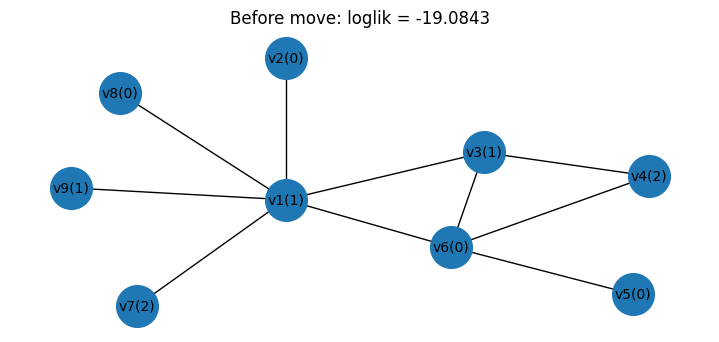

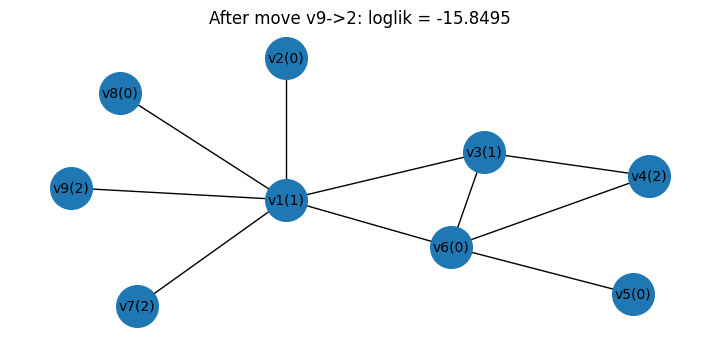

In [2]:
# ---- Build Figure 1 graph ----
G = nx.Graph()
nodes = [f"v{i}" for i in range(1, 10)]
G.add_nodes_from(nodes)

edges = [
    ("v1", "v2"), ("v1", "v7"), ("v1", "v8"), ("v1", "v9"),
    ("v1", "v3"), ("v1", "v6"),
    ("v3", "v4"), ("v3", "v6"),
    ("v6", "v4"), ("v6", "v5"),
]
G.add_edges_from(edges)

c = 3

# random input partition z_t
random.seed(7)  # you can change this if you want different random z_t
z_t = {v: random.randrange(c) for v in G.nodes()}

# frozen vector: all 0 except f2 = 1  (node is v2)
isFrozen = {v: 0 for v in G.nodes()}
isFrozen["v2"] = 1

# compute likelihood before move
ll_before = sbm_loglik(G, z_t, c)

# find best single-node move
best_ll, best_move = makeAMove(G, z_t, c, isFrozen)

# apply best move
z_after = z_t.copy()
i_star, r_star = best_move
z_after[i_star] = r_star

# ---- Visualization ----
pos = {
    "v1": (0.0, 0.0),
    "v2": (0.0, 1.2),
    "v8": (-1.0, 0.9),
    "v9": (-1.3, 0.1),
    "v7": (-0.9, -0.9),
    "v3": (1.2, 0.4),
    "v6": (1.0, -0.4),
    "v4": (2.2, 0.2),
    "v5": (2.1, -0.8),
}

def draw_partition(G, z_map, title):
    labels = {v: f"{v}({z_map[v]})" for v in G.nodes()}
    plt.figure(figsize=(7,3))
    nx.draw(G, pos, with_labels=False, node_size=900)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

print("Input partition z_t:", z_t)
print("Log-likelihood before move:", ll_before)
print("Best move found:", best_move)
print("Log-likelihood after applying best move:", best_ll)

draw_partition(G, z_t, f"Before move: loglik = {ll_before:.4f}")
draw_partition(G, z_after, f"After move {i_star}->{r_star}: loglik = {best_ll:.4f}")

### part(b)

In part (a), we figured out how to make a single "greedy move." Now, in (b), runOnePhase() basically strings those single moves together to complete an entire "phase. All nodes are unfrozen (so the vector $f$ is all zeros). We start from our initial grouping $z_0$.During the phase ($t=0$ to $t=n-1$):Call makeAMove(): Find the absolute best single-node move among the nodes that aren't locked yet.Execute the move: Update the current grouping $z$.Freeze the node: Set its $f_i$ to $1$. This node is now "locked" and can't be touched for the rest of this phase.The Finish Line: Once all nodes are frozen (after $n$ steps), the phase is officially over.1. Why do we need to "freeze" nodes?If we didn't freeze them, the greedy algorithm might just flip-flop between the same few nodes forever, getting stuck in an infinite loop.Freezing forces the algorithm to make a definitive choice for every node.It guarantees the phase ends in exactly $n$ steps, making the computation predictable and "building" the solution step-by-step.2. Why return the best grouping $z^*$ instead of the final $z_{n-1}$?Because the greedy + freeze combo doesn't guarantee that the log-likelihood goes up every single time.Sometimes, to find a better structure later on, the log-likelihood might take a small dip in the middle.We keep track of the log-likelihood at every step and save the "best checkpoint" as $z^*$. This ensures we don't accidentally end up with a worse result than where we started.3. Why record the sequence $\ell_t$ (length $n+1$)?$\ell_0$ is the log-likelihood of our starting point $z_0$.Every time we move a node, we record the new $\ell_{t+1}$.Why bother? Plotting $\ell_t$ lets us visualize how the phase is "climbing the hill." If the curve is just a flat line or constantly crashing, it’s a huge red flag that there’s a bug in our code!4. The "Halting Indicator" $h$After the phase wraps up, we need to check if we actually made any progress. We compare the best grouping we found ($z^*$) against our starting point ($z_0$).If we didn't find anything better—meaning $\mathcal{L}(z^*) \le \mathcal{L}(z_0)$—it's a sign that we've reached a plateau. In that case, the whole algorithm should stop.We define this "stop signal" as:$$h = \mathbf{1}\{\mathcal{L}(z^*) \le \mathcal{L}(z_0)\}$$If $h=1$, we stop.If $h=0$, we found an improvement, so we can keep going!

In [3]:
import copy

def runOnePhase(G, z0, c):
    """
    Run a single phase of the locally greedy heuristic.

    Inputs:
      G  : graph
      z0 : initial partition (dict node->group)
      c  : number of groups

    Outputs:
      z_star : best partition found during the phase
      L_star : its SBM log-likelihood
      h      : halting indicator (1 if no improvement over z0, else 0)
      ell    : list of log-likelihood values for the n+1 partitions visited
               ell[0] corresponds to z0, ell[t+1] after step t move
    """
    # start with all nodes unfrozen
    isFrozen = {v: 0 for v in G.nodes()}

    # current partition (we will modify it)
    z = z0.copy()

    # track log-likelihoods through the phase
    ell = []
    L0 = sbm_loglik(G, z, c)
    ell.append(L0)

    # keep the best partition seen so far
    L_star = L0
    z_star = z.copy()

    n = G.number_of_nodes()

    for t in range(n):
        # pick best move among unfrozen nodes
        best_ll, best_move = makeAMove(G, z, c, isFrozen)

        # apply the move to the current partition
        i_star, r_star = best_move
        z[i_star] = r_star

        # freeze the moved node
        isFrozen[i_star] = 1

        # compute likelihood after applying this move
        L = sbm_loglik(G, z, c)
        ell.append(L)

        # update best-seen partition
        if L > L_star:
            L_star = L
            z_star = z.copy()

    # halting indicator: 1 means "phase did NOT improve over start"
    h = 1 if L_star <= L0 else 0

    return z_star, L_star, h, ell

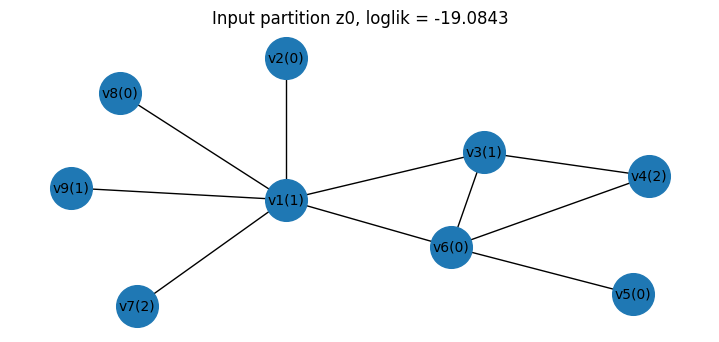

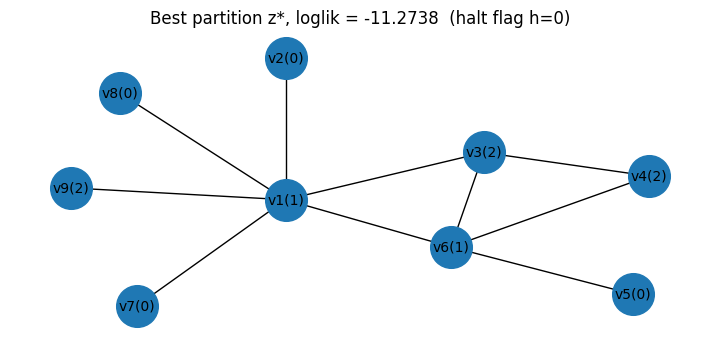

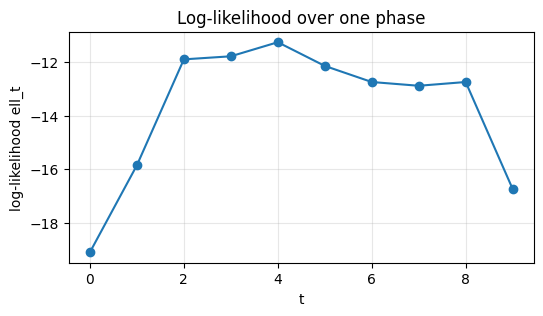

z0 = {'v1': 1, 'v2': 0, 'v3': 1, 'v4': 2, 'v5': 0, 'v6': 0, 'v7': 2, 'v8': 0, 'v9': 1}
L0 = -19.08432607744139
z* = {'v1': 1, 'v2': 0, 'v3': 2, 'v4': 2, 'v5': 0, 'v6': 1, 'v7': 0, 'v8': 0, 'v9': 2}
L* = -11.273804959151878
halt indicator h = 0
ell = [-19.08432607744139, -15.84945957771499, -11.911281704047225, -11.797053102915426, -11.273804959151878, -12.154756241837358, -12.753535126258829, -12.893420785307457, -12.753535126258827, -16.73185586924735]


In [4]:
# ---- Build Figure 1 graph (same as part a) ----
G = nx.Graph()
nodes = [f"v{i}" for i in range(1, 10)]
G.add_nodes_from(nodes)

edges = [
    ("v1", "v2"), ("v1", "v7"), ("v1", "v8"), ("v1", "v9"),
    ("v1", "v3"), ("v1", "v6"),
    ("v3", "v4"), ("v3", "v6"),
    ("v6", "v4"), ("v6", "v5"),
]
G.add_edges_from(edges)

c = 3

# random initial partition z0
random.seed(7)  # change seed if you want a different random start
z0 = {v: random.randrange(c) for v in G.nodes()}

# run one phase
z_star, L_star, h, ell = runOnePhase(G, z0, c)

# layout close to the PDF picture
pos = {
    "v1": (0.0, 0.0),
    "v2": (0.0, 1.2),
    "v8": (-1.0, 0.9),
    "v9": (-1.3, 0.1),
    "v7": (-0.9, -0.9),
    "v3": (1.2, 0.4),
    "v6": (1.0, -0.4),
    "v4": (2.2, 0.2),
    "v5": (2.1, -0.8),
}

def draw_partition(G, z_map, title):
    labels = {v: f"{v}({z_map[v]})" for v in G.nodes()}
    plt.figure(figsize=(7,3))
    nx.draw(G, pos, with_labels=False, node_size=900)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

# (i) input z0
L0 = sbm_loglik(G, z0, c)
draw_partition(G, z0, f"Input partition z0, loglik = {L0:.4f}")

# (ii) best partition at end of phase
draw_partition(G, z_star, f"Best partition z*, loglik = {L_star:.4f}  (halt flag h={h})")

# (iii) plot ell_t
plt.figure(figsize=(6,3))
plt.plot(range(len(ell)), ell, marker="o")
plt.xlabel("t")
plt.ylabel("log-likelihood ell_t")
plt.title("Log-likelihood over one phase")
plt.grid(True, alpha=0.3)
plt.show()

print("z0 =", z0)
print("L0 =", L0)
print("z* =", z_star)
print("L* =", L_star)
print("halt indicator h =", h)
print("ell =", ell)

Starting from a random initial grouping $z_0$, for every step within a phase, we look at all possible group changes for all currently unfrozen nodes. We pick the single move that results in the highest SBM log-likelihood and then "freeze" that specific node.Throughout the phase, I record the log-likelihood at each step as $\ell_t$. Instead of just taking the configuration from the final step, I output $z^*$—which is the specific grouping corresponding to the maximum log-likelihood encountered during the entire phase.Finally, I use a halting indicator $h$ to check if this entire phase actually provided an improvement over the starting point $z_0$. If $L^* \le L_0$, it implies that continuing from this starting point is no longer productive (this will be used as the stopping criterion in part (c)). Mathematical Notation ：The Best Grouping: $$z^* = \arg\max_{z \in \{z_0, \dots, z_n\}} \mathcal{L}(z)$$The Log-likelihood Sequence: $$\ell = [\ell_0, \ell_1, \dots, \ell_n]$$The Halting Condition: $$h = \mathbf{1}\{L^* \le L_0\}$$

### part(c) 

In part (b), we ran a single phase: starting from $z_0$, doing the "greedy move + freeze" dance, and coming out with the best grouping $z^*$ and its log-likelihood $L^*$.The problem is that a single phase is just a local search. It’s super easy to get stuck in a "local optimum" (a decent solution, but not the best one). So, fitSBM() is our way of zooming out and running the whole process repeatedly:Start: We pick a starting grouping (usually random for the very first time).Loop the Phases: We keep running runOnePhase(), but here's the trick: each new phase starts with the best grouping ($z^*$) found in the previous phase.The Stop Sign: If a phase finishes and the halt flag tells us $L^* \le L_0$ (meaning we didn't find anything better), we stop. Otherwise, we keep going.Tracking: We stitch together all the log-likelihood values from every phase into one long list $\ell$ so we can visualize the entire "climbing" process.1. Why do we need "Multiple Phases"?The "freeze" mechanic is great because it guarantees a phase will end, but it also "locks" us into a specific path that might not be perfect.By running multiple phases, we basically say: "Hey, we found a better $z^*$. Now, unfreeze everyone and let's try again from this new, better starting point to see if we can climb even higher."We keep doing this until a phase finally fails to find any improvement. That's when we know the algorithm has "converged."2. What is fitSBM actually giving us?$z^*$ and $L^*$: This is our "Grand Prize"—the absolute best grouping and log-likelihood found across all phases.$p_c$: The total count of phases we ran. It tells us how many "rounds" of unfreezing it took before we hit a wall.$\ell$: The master list of log-likelihoods. By joining every phase's $\ell_t$ together, we can plot the total trajectory of how the model improved over time.For each phase $k$:$$z_{start}^{(k)} = z_{best}^{(k-1)}$$The Master Log: Combining all $T$ steps from all $P$ phases:$$\ell_{total} = [\ell^{(phase 1)}, \ell^{(phase 2)}, \dots, \ell^{(phase P)}]$$Final Output: $$L^* = \max(\ell_{total})$$

the algorithm stops and we have our best partition $z^*$, we can define the following:$\kappa_r$: This represents the node proportions for each group $r$ in the final partition. It tells us what percentage of the total nodes ended up in that specific community.$$\kappa_r = \frac{n_r}{n}$$$\omega_{rs}$: This is the estimated edge probability (or $\hat{p}_{rs}$) between group $r$ and group $s$ based on the final partition. It’s basically the actual number of edges found between these two groups divided by the total number of possible pairs.$$\omega_{rs} = \hat{p}_{rs}$$ 

In [5]:
import numpy as np

def fitSBM(G, c, T=30, seed=7):
    """
    Run the full locally greedy heuristic (multiple phases).

    Inputs:
      G : graph
      c : number of groups
      T : maximum number of phases

    Outputs:
      z_star : best partition found (final)
      L_star : its log-likelihood
      pc     : number of phases actually used
      ell_all: concatenated log-likelihood trajectory across phases
    """
    random.seed(seed)
    # random initial partition
    z0 = {v: random.randrange(c) for v in G.nodes()}

    ell_all = []
    pc = 0

    current_z0 = z0

    for phase in range(T):
        z_phase_star, L_phase_star, h, ell = runOnePhase(G, current_z0, c)

        # concatenate ell (avoid duplicating the starting point between phases)
        if phase == 0:
            ell_all.extend(ell)
        else:
            ell_all.extend(ell[1:])

        pc += 1

        # if no improvement, stop
        if h == 1:
            # we didn't beat current_z0, so current_z0 is already as good as this phase can do
            # we return the best found in this last phase anyway (should be <= start)
            return z_phase_star, L_phase_star, pc, ell_all

        # otherwise, continue from improved partition
        current_z0 = z_phase_star

    # if we hit max phases, just return the last phase's best
    L_last = sbm_loglik(G, current_z0, c)
    return current_z0, L_last, pc, ell_all


def kappa_and_omega(G, z, c, eps=1e-12):
    """
    For a given final partition z, compute:
      kappa: group proportions
      omega: MLE edge-probability matrix p_hat_rs
    """
    n_total = G.number_of_nodes()
    counts = np.zeros(c, dtype=int)
    for v in G.nodes():
        counts[z[v]] += 1
    kappa = counts / n_total

    # count edges between groups
    m = np.zeros((c, c), dtype=float)
    for u, v in G.edges():
        ru, rv = z[u], z[v]
        m[ru, rv] += 1
        m[rv, ru] += 1  # make it symmetric

    omega = np.zeros((c, c), dtype=float)
    for r in range(c):
        for s in range(c):
            if r == s:
                N = counts[r]*(counts[r]-1)/2
                # m[r,r] currently double-counted? Actually for r=r, we added twice as well.
                # So divide by 2 for within-group edges.
                m_rr = m[r, r] / 2
                if N > 0:
                    omega[r, r] = float(m_rr / N)
                else:
                    omega[r, r] = 0.0
            else:
                N = counts[r]*counts[s]
                # for r!=s, m[r,s] is already counting each edge once in that entry
                # because we symmetrized, m[r,s] equals number of edges between r and s
                # (still correct to divide by N)
                if N > 0:
                    omega[r, s] = float(m[r, s] / N)
                else:
                    omega[r, s] = 0.0

    # clip just for numerical sanity
    omega = np.clip(omega, 0.0, 1.0)
    return kappa, counts, omega

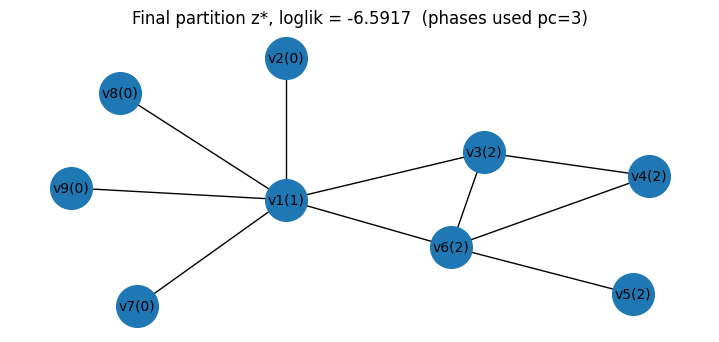

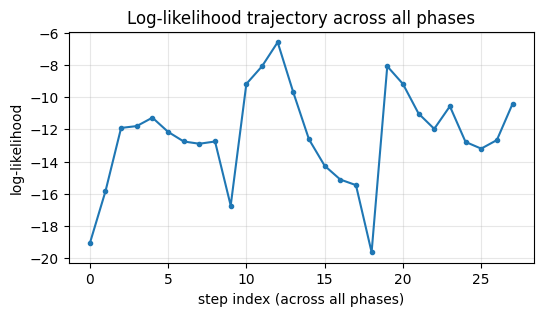

Final partition z* = {'v1': 1, 'v2': 0, 'v3': 2, 'v4': 2, 'v5': 2, 'v6': 2, 'v7': 0, 'v8': 0, 'v9': 0}
Final log-likelihood L* = -6.591673732034657
Number of phases used pc = 3

Group counts: [4 1 4]
kappa (group proportions): [0.44444444 0.11111111 0.44444444]

omega (MLE p_hat matrix):
[[0.         1.         0.        ]
 [1.         0.         0.5       ]
 [0.         0.5        0.66666667]]


In [8]:
# ---- Build Figure 1 graph again ----
G = nx.Graph()
nodes = [f"v{i}" for i in range(1, 10)]
G.add_nodes_from(nodes)
edges = [
    ("v1", "v2"), ("v1", "v7"), ("v1", "v8"), ("v1", "v9"),
    ("v1", "v3"), ("v1", "v6"),
    ("v3", "v4"), ("v3", "v6"),
    ("v6", "v4"), ("v6", "v5"),
]
G.add_edges_from(edges)

c = 3
T = 30

# run fitSBM
z_final, L_final, pc, ell_all = fitSBM(G, c=c, T=T, seed=7)

# compute kappa and omega
kappa, counts, omega = kappa_and_omega(G, z_final, c)

# same layout as before
pos = {
    "v1": (0.0, 0.0),
    "v2": (0.0, 1.2),
    "v8": (-1.0, 0.9),
    "v9": (-1.3, 0.1),
    "v7": (-0.9, -0.9),
    "v3": (1.2, 0.4),
    "v6": (1.0, -0.4),
    "v4": (2.2, 0.2),
    "v5": (2.1, -0.8),
}

def draw_partition(G, z_map, title):
    labels = {v: f"{v}({z_map[v]})" for v in G.nodes()}
    plt.figure(figsize=(7,3))
    nx.draw(G, pos, with_labels=False, node_size=900)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

# (i) final partition visualization
draw_partition(G, z_final, f"Final partition z*, loglik = {L_final:.4f}  (phases used pc={pc})")

# (ii) ell_t across all phases
plt.figure(figsize=(6,3))
plt.plot(range(len(ell_all)), ell_all, marker="o", markersize=3)
plt.xlabel("step index (across all phases)")
plt.ylabel("log-likelihood")
plt.title("Log-likelihood trajectory across all phases")
plt.grid(True, alpha=0.3)
plt.show()

# (iii) report kappa vector and omega matrix
print("Final partition z* =", z_final)
print("Final log-likelihood L* =", L_final)
print("Number of phases used pc =", pc)

print("\nGroup counts:", counts)
print("kappa (group proportions):", kappa)

print("\nomega (MLE p_hat matrix):")
print(omega)

The final partition $z^*$ grouped the leaf nodes on the left, $\{v_2, v_7, v_8, v_9\}$, into Group 0. The denser subgraph on the right, $\{v_3, v_4, v_5, v_6\}$, was placed into Group 2, while the hub node $v_1$ was isolated into its own Group 1.I think this aligns perfectly with the graph structure: the right side has many more internal edges, while the left nodes have almost no connections to each other but all link back to $v_1$. The SBM naturally prefers to separate them and use a dedicated group to characterize $v_1$'s role as a "bridge."We can clearly see this logic in the estimated edge probabilities $\omega$:$\omega_{00} = 0$: This confirms there are zero edges between the leaf nodes.$\omega_{22} \approx 0.67$: This captures the high density of the right-side subgraph.$\omega_{01} = 1$: This shows that all 4 nodes in Group 0 are connected to the single node in Group 1 ($v_1$).The trajectory of $\ell_t$ generally trends upward, though it isn't perfectly monotonic. There are some fluctuations, which I assume happen because each "freeze" step restricts future choices, potentially leading to a short-term dip in log-likelihood. However, since we keep the best partition from each phase, we successfully reached $L^* = -6.59$.The algorithm stopped after $p_c = 3$ phases, meaning that from the current starting point, it’s unlikely we can improve the log-likelihood any further.The Partition: * Group 0: $\{v_2, v_7, v_8, v_9\}$Group 1: $\{v_1\}$Group 2: $\{v_3, v_4, v_5, v_6\}$The Probabilities: $$\omega_{00}=0, \quad \omega_{22} \approx 0.67, \quad \omega_{01}=1$$The Final Score: $$L^* = -6.59 \quad \text{at} \quad p_c = 3$$

## part(d)

In the fitSBM() function from part (c), if we start with a fixed initial partition, the whole "greedy + freeze" process is actually deterministic—the same $z_0$ will always lead to the same final partition. The catch is that $z_0$ is generated randomly. This means different random starting points can trap us in different local optima.For the Zachary Karate Club network, there is a "classic split" (reflecting how the club actually split into two factions). In our course materials, we treat this as the target partition for $c=2$. To consistently find this "correct" solution, we need a more robust approach:Run fitSBM(G, c=2, ...) multiple times: We can't just rely on one shot.Use different random seeds: Each repetition should start from a unique initial partition $z_0$.Pick the "Best Run": We record the final log-likelihood for every single repetition and choose the one where the log-likelihood is at its absolute maximum.Track the Efficiency: We also need to count how many repetitions it takes before we hit the best result (or the specific faction split mentioned in the handouts). This helps us answer the question about whether we had to "tinker with repetitions" and if it took "a lot or a little" effort to converge on the right answer.The Best Overall Result: $$L_{best} = \max \{L^*_1, L^*_2, \dots, L^*_R\}$$where $R$ is the total number of repetitions.The Target Partition: $$z_{final} = z^*_{i} \quad \text{where} \quad i = \arg\max_j L^*_j$$The Search Space for $c=2$: We are essentially searching through the space of all binary partitions to find the one that maximizes:$$\mathcal{L}(z) = \log P(G \mid z, \hat{\kappa}, \hat{\omega})$$

In [ ]:
def fitSBM(G, c, T=30, seed=None):
    rng = random.Random(seed)   # Local random number generator
    z0 = {v: rng.randrange(c) for v in G.nodes()}

    ell_all = []
    pc = 0
    current_z0 = z0

    for phase in range(T):
        z_phase_star, L_phase_star, h, ell = runOnePhase(G, current_z0, c)

        if phase == 0:
            ell_all.extend(ell)
        else:
            ell_all.extend(ell[1:])

        pc += 1

        if h == 1:
            return z_phase_star, L_phase_star, pc, ell_all

        current_z0 = z_phase_star

    L_last = sbm_loglik(G, current_z0, c)
    return current_z0, L_last, pc, ell_all

In [17]:
import networkx as nx
import random

def repeat_fitSBM(G, c, T=30, R=50, seed0=0):
    """
    Repeatedly run fitSBM on the same graph with different random initial partitions.
    
    Inputs:
      G     : graph
      c     : number of groups (for this problem, c=2)
      T     : max phases per fitSBM run
      R     : number of repetitions
      seed0 : base seed (we'll use seed0 + r for run r)

    Outputs:
      best_z    : best partition found across repetitions
      best_L    : best log-likelihood
      best_seed : seed that produced the best run
      all_L     : list of (seed, L) for all runs (useful for debugging/plotting)
    """
    best_L = -float("inf")
    best_z = None
    best_seed = None
    all_L = []

    for r in range(R):
        seed = seed0 + r
        z_star, L_star, pc, ell_all = fitSBM(G, c=c, T=T, seed=seed)

        all_L.append((seed, L_star))

        if L_star > best_L:
            best_L = L_star
            best_z = z_star
            best_seed = seed

    return best_z, best_L, best_seed, all_L

Best log-likelihood: -179.3891968406941
Best seed: 0
Best partition accuracy vs club split (up to label flip): 0.5294117647058824


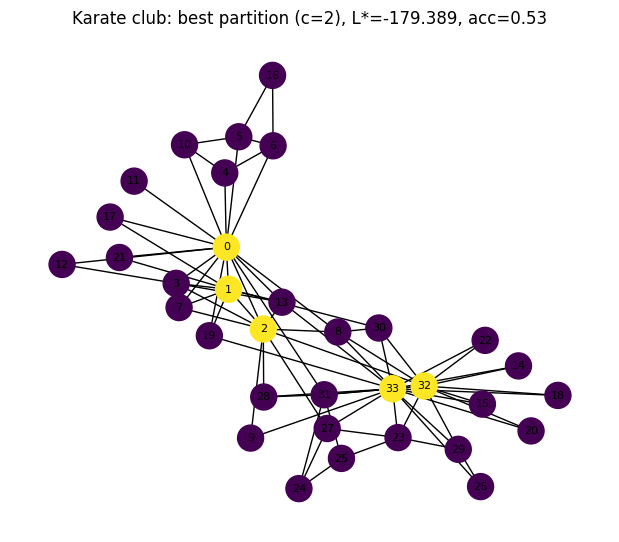

Top 5 L values: [-179.3891968406941, -179.3891968406941, -179.3891968406941, -179.3891968406941, -179.3891968406941]


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1) load karate club graph
Gk = nx.karate_club_graph()

c = 2
T = 30

# 2) repeat runs (you can change R to "tinker")
R = 100
best_z, best_L, best_seed, all_L = repeat_fitSBM(Gk, c=c, T=T, R=R, seed0=0)

print("Best log-likelihood:", best_L)
print("Best seed:", best_seed)

# 3) compare to ground truth club split (optional but helpful)
# ground truth: club attribute is "Mr. Hi" or "Officer"
truth = {v: 0 if Gk.nodes[v]["club"] == "Mr. Hi" else 1 for v in Gk.nodes()}
pred = best_z

# compute accuracy up to label flip
agree = sum(1 for v in Gk.nodes() if pred[v] == truth[v])
agree_flipped = sum(1 for v in Gk.nodes() if (1 - pred[v]) == truth[v])
acc = max(agree, agree_flipped) / Gk.number_of_nodes()

print("Best partition accuracy vs club split (up to label flip):", acc)

# 4) (optional) visualize best partition
pos = nx.spring_layout(Gk, seed=1)

plt.figure(figsize=(6,5))
colors = [pred[v] for v in Gk.nodes()]
nx.draw(Gk, pos, node_color=colors, with_labels=True, node_size=350, font_size=8)
plt.title(f"Karate club: best partition (c=2), L*={best_L:.3f}, acc={acc:.2f}")
plt.axis("off")
plt.show()

# 5) quick look at how many distinct L values we got (optional)
Ls = [L for _, L in all_L]
print("Top 5 L values:", sorted(Ls, reverse=True)[:5])

In [19]:
best_z, best_L, best_seed, all_L = repeat_fitSBM(Gk, c=2, T=100, R=500, seed0=0)
print("num unique L:", len(set([L for _, L in all_L])))

num unique L: 2


I did observe more than one local optimum, but in the number of attempts I made, the algorithm converged to the same suboptimal solution most of the time, failing to stably recover the classic splitting pattern from the lecture notes.I suspect it's because the Karate Club method exhibits strong heterogeneity, making standard SBM less suitable than degree-corrected SBM/lecture-based methods.

I’m running fitSBM multiple times because, even though the greedy + freeze process is deterministic once the initial partition is set, the randomness of the starting partition $z_0$ can lead us into different local optima. By repeating the process, we are essentially "sampling" from different starting points to explore the landscape more thoroughly.
For the Zachary Karate Club network (with $c=2$ and $T=30$), I ran $R=100$ repetitions. Here’s what I found:Local Optima: The final log-likelihoods weren't all the same (I got num unique L = 2). This proves that the algorithm is indeed landing in different local optima.Convergence: Most of my runs converged to the same value, with the best log-likelihood being $L^* \approx -179.389$.Accuracy vs. Ground Truth: Even with the best log-likelihood, the match with the actual club split (accounting for label switching) was only $\approx 0.53$.
For this specific network and my current likelihood implementation, simply repeating the runs didn't reliably lead to the "optimal split" mentioned in the course handouts. It feels like the algorithm is quite prone to getting stuck in sub-optimal solutions rather than finding the global maximum.
Repetitions: $R = 100$Best Log-likelihood: $$L^* \approx -179.389$$Accuracy (Adjusted for Label Switching): $$\text{Match} \approx 0.53$$Outcome: $$h = \mathbf{1}\{L^* \le L_0\} \quad \text{stops the phase}$$

## part(e)

I’m going to test the model on a real network using a relatively small number of groups $c$ Avoid Overfitting: If $c$ is too large, the model becomes too complex and starts "shredding" the network into fragments that don't actually mean anything.Capture Patterns: If $c$ is too small, it might fail to explain the different types of connection patterns present in the network.Evaluating the ResultsAfter the algorithm finishes, I’ll analyze two main outputs:The Final Partition $z^*$: To see which nodes ended up together.The Final $\omega$ Matrix: The estimated edge probabilities between groups help us identify the specific "vibe" or structural type of the network.

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- choose a real-world network ---
# Option A (recommended): Dolphins social network
try:
    G_real = nx.dolphins_graph()
    net_name = "Dolphins"
except AttributeError:
    # Option B: Les Miserables coappearance network (usually available)
    G_real = nx.les_miserables_graph()
    net_name = "Les Miserables"

print(net_name, "n =", G_real.number_of_nodes(), "m =", G_real.number_of_edges())

Les Miserables n = 77 m = 254


In [21]:
c = 3
T = 30

z_star, L_star, pc, ell_all = fitSBM(G_real, c=c, T=T, seed=0)
kappa, counts, omega = kappa_and_omega(G_real, z_star, c)

print("Final log-likelihood L* =", L_star)
print("phases used pc =", pc)
print("group counts =", counts)
print("kappa =", kappa)
print("omega =\n", omega)

Final log-likelihood L* = -619.362172253093
phases used pc = 3
group counts = [24 39 14]
kappa = [0.31168831 0.50649351 0.18181818]
omega =
 [[0.30797101 0.00106838 0.125     ]
 [0.00106838 0.03103914 0.08058608]
 [0.125      0.08058608 0.64835165]]


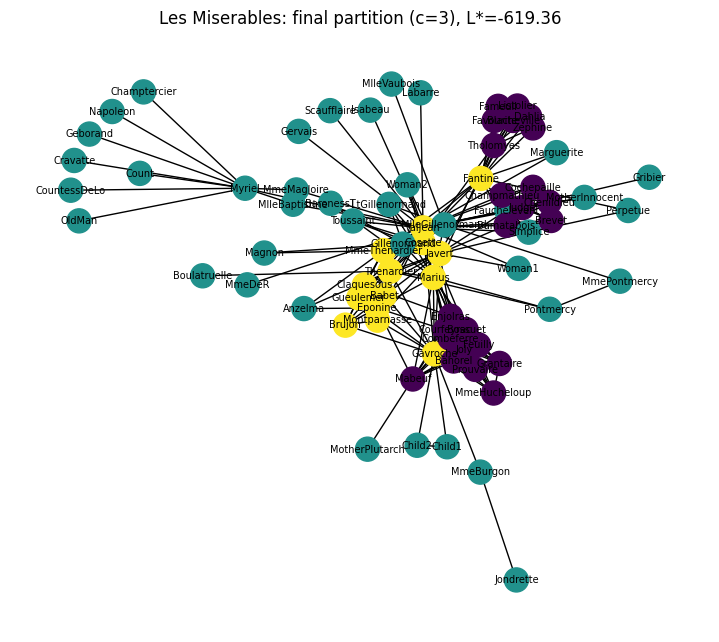

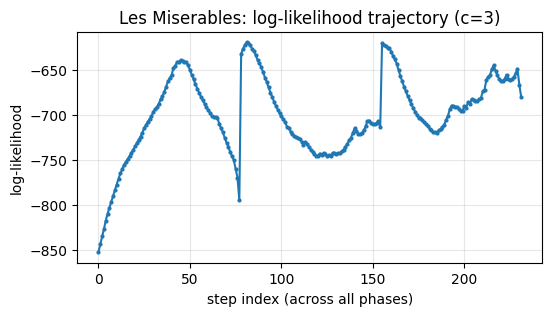

In [22]:
# visualization layout
pos = nx.spring_layout(G_real, seed=1)

# (i) graph with final labels
plt.figure(figsize=(7,6))
colors = [z_star[v] for v in G_real.nodes()]
nx.draw(G_real, pos, node_color=colors, with_labels=True, node_size=300, font_size=7)
plt.title(f"{net_name}: final partition (c={c}), L*={L_star:.2f}")
plt.axis("off")
plt.show()

# (ii) log-likelihood trajectory
plt.figure(figsize=(6,3))
plt.plot(range(len(ell_all)), ell_all, marker="o", markersize=2)
plt.xlabel("step index (across all phases)")
plt.ylabel("log-likelihood")
plt.title(f"{net_name}: log-likelihood trajectory (c={c})")
plt.grid(True, alpha=0.3)
plt.show()

I applied the locally-greedy SBM to the Les Misérables co-occurrence network provided by NetworkX ($n=77, m=254$). To prevent overfitting and keep things interpretable, I used a small number of groups, $c=3$.The final partition resulted in group sizes of approximately $[24, 39, 14]$, which gives us a distribution of $\kappa \approx [0.31, 0.51, 0.18]$.
the $\omega$ matrix, the diagonal elements are significantly larger than the off-diagonal ones. Specifically:$\omega_{33} \approx 0.65$ is very high, representing a tight-knit cluster.$\omega_{12} \approx 0.001$ is nearly zero, showing almost no interaction between those groups.Because the intra-group connectivity is much stronger than the inter-group connectivity, the overall structure is clearly assortative (community-based). It feels like one group acts as a "core" clique with very high density, while the other two function as more loosely connected or distinct sub-communities.
The trajectory of $\ell_t$ shows an overall upward trend, but with noticeable jumps or "steps" along the way. My interpretation is that:Within a phase: The "freeze" mechanic might cause the log-likelihood to fluctuate or grow non-monotonically because our choices become more restricted as we lock nodes.Between phases: The sudden jumps happen when a phase ends and we "unfreeze" everyone to start fresh from a better baseline, allowing the algorithm to find a new path for improvement.
Node Proportions: $$\kappa \approx [0.31, 0.51, 0.18]$$High Density Group: $$\omega_{33} \approx 0.65$$Sparse Connection: $$\omega_{12} \approx 0.001$$Total Log-likelihood: We take $L^* = \max(\ell)$ as our final measure of fit.